In [1]:
from tradepy.data.loader import load_future
from tradepy.config.config import load_config, load_symbols, load_feature_config, load_exclude_config
from tradepy.data.cleaner import add_trading_date_by_gap
from tradepy.data.resampler import resample_ohlcv, daily_ohlcv_cummulative
from tradepy.features.generate import generate_features
from tradepy.features.quality_check import data_quality_report
from tradepy.supervised.load import prepare_all
from tradepy.paths import EXCLUDE_CONFIG, SYSTEM_CONFIG
from tradepy.supervised.target import target_triple_barrier_interday
from tradepy.supervised.pretrain import filter_features
from tradepy.supervised.models import GoldLSTM_L1_Move, GoldLSTM_L2_Dir, GoldGRU_L1_Move, GoldGRU_L2_Dir, BasicLSTM_L1_Move, BasicLSTM_L2_Dir, BasicGRU_L1_Move, BasicGRU_L2_Dir, BasicLSTM_L3_Regression, BasicGRU_L3_Regression
from tradepy.supervised.train import train_walk_forward_2level, grid_search_thresholds, create_lstm_dataset
from tradepy.supervised.posttrain import evaluate_model_classification, tune_threshold_wf, save_trading_model_2level
from tradepy.paths import MODELS_DIR

In [2]:
symbols = load_symbols()
cfg = load_config()

In [3]:
symbols


['AD',
 'BP',
 'CL',
 'EC',
 'ES',
 'GC',
 'MFXI',
 'NG',
 'NQ',
 'YM',
 'ZB',
 'ZN',
 'ZS']

In [4]:
ASSET = symbols[5]
MINUTES             = cfg['sampling_minutes']        # 240
RETURN_HORIZON_MIN  = cfg['return_horizon_min']      # 2880

In [5]:
df_final, spec = prepare_all(ASSET, MINUTES, RETURN_HORIZON_MIN, json_config_path="../Data/features_config.json")


In [6]:
exclude = load_exclude_config(MINUTES)

In [7]:
df_final_triple_real = target_triple_barrier_interday(df_final, spec, return_horizon_days=int(RETURN_HORIZON_MIN/60/24), profit_factor=1.8, tp_atr_mult=1.4, sl_atr_mult=1.2)
df_final_triple_real["target_class"] = df_final_triple_real[f"target_tb_{int(RETURN_HORIZON_MIN/60/24)}d"]
df_final_triple_real["target_regression"] = df_final_triple_real[f"log_return_horizon_{RETURN_HORIZON_MIN}m"]

In [8]:
feature_cols_triple = [c for c in df_final_triple_real.columns if c not in exclude['exclude_cols_triple']]

In [9]:
df_final_triple_real = df_final_triple_real.dropna(subset=["target_class", "target_regression"])

In [10]:
features_finales_test, params = filter_features(df_final_triple_real, feature_cols_triple, 'target_class', horizon_min=RETURN_HORIZON_MIN, sampling_minutes=MINUTES)

Eliminando 54 features redundantes por correlación
Configuración sugerida:
{'lookback': 30, 'train_size': 6000, 'test_size': 180, 'gap': 12, '_candles_per_day': 6, '_horizon_bars': 12}
Features seleccionadas (61):
['volume_cum' 'macd' 'signal' 'histogram' 'adx' 'rsi' 'slowk' 'cmo'
 'williams_r' 'cci' 'roc_10' 'roc_5' 'hv' 'obv' 'obv_norm' 'obv_roc_5'
 'obv_roc_10' 'obv_z' 'obv_rel' 'ad_roc_5' 'ad_roc_10' 'ad_z' 'ad_rel'
 'volume_range' 'volume_price' 'mfi' 'cmf' 'efi' 'avg_volume'
 'relative_volume' 'volume_delta' 'pct_above_ma_20' 'pct_above_ma_50'
 'slope_10' 'dist_low_cum_ticks' 'dist_open_day_ticks'
 'vol_weight_intraday' 'hour' 'hour_sin' 'is_ny' 'return_lag_1'
 'return_lag_5' 'return_lag_10' 'return_lag_20' 'return_std_5'
 'return_std_10' 'bb_width' 'rolling_skew_10' 'rolling_kurt_10'
 'rolling_skew_20' 'rolling_kurt_20' 'dist_to_last_swing_high'
 'dist_to_last_swing_low' 'swing_range' 'swing_range_pct'
 'close_in_swing_range' 'atr_norm' 'atr_z' 'dist_to_nearest_fib'
 'swing_high

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import RobustScaler
from tqdm import tqdm

def train_walk_forward_3level(
    df,
    feature_cols,
    target_col,           # columna original: 0=SELL, 1=HOLD, 2=BUY
    logreturn_col,        # columna con log_return del triple barrier
    model_class_l1,       # GoldLSTM_L1_Move
    model_class_l2,       # GoldLSTM_L2_Dir
    model_class_l3,       # Red de regresión (output_dim=1)
    train_size=40000,
    test_size=10000,
    gap=2,
    lookback=24,
    epochs=15,
    batch_size=256,
    lr=5e-4
):
    """
    Entrenamiento en 3 niveles libre de NaNs que registra las pérdidas históricas por Época y Fold.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    all_results = []
    losses_records = []  # Lista para acumular el historial de pérdidas
    fold_count = 1       # Contador identificador de cada ventana walk-forward

    # 1. LIMPIEZA PREVENTIVA CRÍTICA
    df = df.dropna(subset=feature_cols + [target_col, logreturn_col]).reset_index(drop=True)

    df = df.copy()
    df['_target_l1'] = (df[target_col] != 1).astype(int)
    df['_target_l2'] = (df[target_col] == 2).astype(int)
    df['_target_l3'] = df[logreturn_col]

    # Generar secuencias contiguas limpias para todos los targets
    X_all, y_dict = create_lstm_dataset(
        df,
        feature_cols,
        {'_target_l1': '_target_l1', '_target_l2': '_target_l2', '_target_l3': '_target_l3'},
        lookback
    )
    y_l1_all = y_dict['_target_l1']
    y_l2_all = y_dict['_target_l2']
    y_l3_all = y_dict['_target_l3']

    dt_all = df['datetime'].values[lookback:]
    total_samples = len(X_all)

    for start in tqdm(range(0, total_samples - train_size - test_size - gap, test_size), desc="WF 3-Level"):

        train_end = start + train_size
        test_start = train_end + gap
        test_end = test_start + test_size

        # --- SPLIT ---
        X_train = X_all[start:train_end]
        X_test = X_all[test_start:test_end]
        y_l1_train = y_l1_all[start:train_end]
        y_l1_test = y_l1_all[test_start:test_end]
        y_l2_train = y_l2_all[start:train_end]
        y_l3_train = y_l3_all[start:train_end]
        dt_test = dt_all[test_start:test_end]

        # --- ESCALADO FEATURES ---
        sc = RobustScaler()
        N_train, L, F = X_train.shape
        X_train_scaled = sc.fit_transform(X_train.reshape(-1, F)).reshape(N_train, L, F)
        N_test = X_test.shape[0]
        X_test_scaled = sc.transform(X_test.reshape(-1, F)).reshape(N_test, L, F)

        # --- ESCALADO L3 ---
        sc_l3 = RobustScaler()
        y_l3_train_scaled = sc_l3.fit_transform(y_l3_train.reshape(-1, 1)).ravel()

        X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
        X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

        # =====================================================
        # NIVEL 1 — ¿Hay movimiento?
        # =====================================================
        y_l1_train_t = torch.tensor(y_l1_train, dtype=torch.long).to(device)

        counts_l1 = np.bincount(y_l1_train.astype(int), minlength=2)
        w_l1 = 1.0 / (counts_l1 / len(y_l1_train) + 1e-6)
        w_l1[1] *= 2.0   
        w_l1 = w_l1 / w_l1.sum()
        w_l1_t = torch.tensor(w_l1, dtype=torch.float32).to(device)

        model_l1 = model_class_l1(input_dim=len(feature_cols), output_dim=2).to(device)
        opt_l1 = torch.optim.Adam(model_l1.parameters(), lr=lr)
        crit_l1 = nn.CrossEntropyLoss(weight=w_l1_t)
        
        loader_l1 = DataLoader(TensorDataset(X_train_t, y_l1_train_t), batch_size=batch_size, shuffle=True)
        sched_l1 = torch.optim.lr_scheduler.OneCycleLR(
            opt_l1, max_lr=lr,
            steps_per_epoch=len(loader_l1),
            epochs=epochs, pct_start=0.3
        )
        scaler_amp = torch.amp.GradScaler(enabled=(device.type == "cuda"))

        # Estructuras locales para almacenar la pérdida promediada de la época
        fold_l1_losses = []
        model_l1.train()
        for epoch in range(epochs):
            running_loss = 0.0
            for bx, by in loader_l1:
                opt_l1.zero_grad()
                with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                    loss = crit_l1(model_l1(bx), by)
                scaler_amp.scale(loss).backward()
                scaler_amp.unscale_(opt_l1)
                nn.utils.clip_grad_norm_(model_l1.parameters(), 1.0)
                scaler_amp.step(opt_l1)
                scaler_amp.update()
                sched_l1.step()
                running_loss += loss.item()
            fold_l1_losses.append(running_loss / len(loader_l1))

        # =====================================================
        # NIVEL 2 & 3 — Solo con movimiento (L1_train == 1)
        # =====================================================
        mask_move = (y_l1_train == 1)
        X_l23_train = X_train_scaled[mask_move]
        y_l2_train_filt = y_l2_train[mask_move]
        y_l3_train_filt = y_l3_train_scaled[mask_move]

        y_l2_train_t = torch.tensor(y_l2_train_filt, dtype=torch.long).to(device)
        y_l3_train_t = torch.tensor(y_l3_train_filt, dtype=torch.float32).to(device)
        X_l23_train_t = torch.tensor(X_l23_train, dtype=torch.float32).to(device)

        # --------- NIVEL 2 ---------
        counts_l2 = np.bincount(y_l2_train_filt.astype(int), minlength=2)
        w_l2 = 1.0 / (counts_l2 / len(y_l2_train_filt) + 1e-6)
        w_l2 = w_l2 / w_l2.sum()
        w_l2_t = torch.tensor(w_l2, dtype=torch.float32).to(device)

        model_l2 = model_class_l2(input_dim=len(feature_cols), output_dim=2).to(device)
        opt_l2 = torch.optim.Adam(model_l2.parameters(), lr=lr)
        crit_l2 = nn.CrossEntropyLoss(weight=w_l2_t)
        
        loader_l2 = DataLoader(TensorDataset(X_l23_train_t, y_l2_train_t), batch_size=batch_size, shuffle=True)
        sched_l2 = torch.optim.lr_scheduler.OneCycleLR(
            opt_l2, max_lr=lr,
            steps_per_epoch=len(loader_l2),
            epochs=epochs, pct_start=0.3
        )

        fold_l2_losses = []
        model_l2.train()
        for epoch in range(epochs):
            running_loss = 0.0
            for bx, by in loader_l2:
                opt_l2.zero_grad()
                with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                    loss = crit_l2(model_l2(bx), by)
                scaler_amp.scale(loss).backward()
                scaler_amp.unscale_(opt_l2)
                nn.utils.clip_grad_norm_(model_l2.parameters(), 1.0)
                scaler_amp.step(opt_l2)
                scaler_amp.update()
                sched_l2.step()
                running_loss += loss.item()
            fold_l2_losses.append(running_loss / len(loader_l2))

        # --------- NIVEL 3 (REGRESIÓN) ---------
        model_l3 = model_class_l3(input_dim=len(feature_cols), output_dim=1).to(device)
        opt_l3 = torch.optim.Adam(model_l3.parameters(), lr=lr)
        crit_l3 = nn.HuberLoss(delta=1.0)
        
        loader_l3 = DataLoader(TensorDataset(X_l23_train_t, y_l3_train_t), batch_size=batch_size, shuffle=True)
        sched_l3 = torch.optim.lr_scheduler.OneCycleLR(
            opt_l3, max_lr=lr,
            steps_per_epoch=len(loader_l3),
            epochs=epochs, pct_start=0.3
        )

        fold_l3_losses = []
        model_l3.train()
        for epoch in range(epochs):
            running_loss = 0.0
            for bx, by in loader_l3:
                opt_l3.zero_grad()
                with torch.amp.autocast("cuda", enabled=(device.type == "cuda")):
                    pred = model_l3(bx).squeeze()
                    loss = crit_l3(pred, by)
                scaler_amp.scale(loss).backward()
                scaler_amp.unscale_(opt_l3)
                nn.utils.clip_grad_norm_(model_l3.parameters(), 1.0)
                scaler_amp.step(opt_l3)
                scaler_amp.update()
                sched_l3.step()
                running_loss += loss.item()
            fold_l3_losses.append(running_loss / len(loader_l3))

        # Registrar las pérdidas organizadas por época de este fold
        for ep in range(epochs):
            losses_records.append({
                'fold': fold_count,
                'epoch': ep + 1,
                'loss_l1_move': fold_l1_losses[ep],
                'loss_l2_dir': fold_l2_losses[ep],
                'loss_l3_reg': fold_l3_losses[ep]
            })

        # =====================================================
        # INFERENCIA COMPLETA (Test)
        # =====================================================
        model_l1.eval()
        model_l2.eval()
        model_l3.eval()

        with torch.no_grad():
            probs_l1 = torch.softmax(model_l1(X_test_t), dim=1).cpu().numpy()
            probs_l2 = torch.softmax(model_l2(X_test_t), dim=1).cpu().numpy()
            logrets_l3_scaled = model_l3(X_test_t).squeeze().cpu().numpy()
            
            if logrets_l3_scaled.ndim == 0:
                logrets_l3_scaled = logrets_l3_scaled.reshape(-1)
            logrets_l3 = sc_l3.inverse_transform(logrets_l3_scaled.reshape(-1, 1)).ravel()

        original_test = df[target_col].values[lookback:][test_start:test_end]
        original_test_reg = df[logreturn_col].values[lookback:][test_start:test_end]

        step_res = pd.DataFrame({
            'fold': fold_count,  # Guardamos también el fold en los resultados del test
            'datetime': dt_test,
            'actual': original_test,
            'prob_hold': probs_l1[:, 0],
            'prob_move': probs_l1[:, 1],
            'prob_sell': probs_l2[:, 0],
            'prob_buy': probs_l2[:, 1],
            'pred_logret': logrets_l3,
            'real_logret': original_test_reg,
        })

        all_results.append(step_res)

        del y_l1_train_t, y_l2_train_t, y_l3_train_t, X_l23_train_t
        torch.cuda.empty_cache()
        
        fold_count += 1

    df_losses = pd.DataFrame(losses_records)
    return pd.concat(all_results, ignore_index=True), all_results, df_losses, model_l1, model_l2, model_l3, sc, sc_l3

In [12]:
result_3, result_by_fold_3, df_losses, model_l1, model_l2, model_l3, sc, sc_l3 = train_walk_forward_3level(df_final_triple_real, features_finales_test, 'target_class', 'target_regression', BasicLSTM_L1_Move, BasicLSTM_L2_Dir, BasicLSTM_L3_Regression, 
                            train_size=params["train_size"],
                            test_size=params["test_size"],
                            gap=params["gap"],
                            lookback=params["lookback"],
                            epochs=15,
                            batch_size=256,
                            lr=5e-4)

WF 3-Level:   0%|          | 0/134 [00:00<?, ?it/s]C:\Users\LIJUN\AppData\Local\Temp\ipykernel_2056\2617823288.py:121: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sched_l1.step()
C:\Users\LIJUN\AppData\Local\Temp\ipykernel_2056\2617823288.py:167: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sched_l2.step

In [13]:
result_3

,fold,datetime,actual,prob_hold,prob_move,prob_sell,prob_buy,pred_logret,real_logret
0,1,2010-10-18 16:00:00,0.0,NaN,NaN,NaN,NaN,NaN,-0.016704
1,1,2010-10-18 20:00:00,1.0,NaN,NaN,NaN,NaN,NaN,-0.011259
2,1,2010-10-19 00:00:00,1.0,NaN,NaN,NaN,NaN,NaN,-0.008217
3,1,2010-10-19 04:00:00,1.0,NaN,NaN,NaN,NaN,NaN,-0.003267
4,1,2010-10-19 08:00:00,1.0,NaN,NaN,NaN,NaN,NaN,-0.008436
...,...,...,...,...,...,...,...,...,...
24115,134,2026-01-13 08:00:00,1.0,0.451255,0.548745,0.459316,0.540684,0.027760,0.027770
24116,134,2026-01-13 12:00:00,1.0,0.375172,0.624828,0.672665,0.327335,0.024817,0.028560
24117,134,2026-01-13 16:00:00,2.0,0.336015,0.663985,0.675290,0.324710,0.022832,0.027746
24118,134,2026-01-13 20:00:00,2.0,0.349066,0.650934,0.697550,0.302450,0.018787,0.018535


In [14]:
result_3.describe()

,fold,datetime,actual,prob_hold,prob_move,prob_sell,prob_buy,pred_logret,real_logret
count,24120.000000,24120,24120.000000,21600.000000,21600.000000,21600.000000,21600.000000,21600.000000,24120.000000
mean,67.500000,2018-06-02 04:24:55.522388,0.988640,0.383410,0.616590,0.496935,0.503065,0.000482,0.000615
min,1.000000,2010-10-18 16:00:00,0.000000,0.005356,0.016877,0.001063,0.001588,-0.061084,-0.143724
25%,34.000000,2014-08-06 11:00:00,1.000000,0.177437,0.428325,0.198334,0.202970,-0.006492,-0.006870
50%,67.500000,2018-06-06 06:00:00,1.000000,0.357397,0.642603,0.490800,0.509200,0.000655,0.000759
75%,101.000000,2022-03-23 13:00:00,1.000000,0.571675,0.822563,0.797030,0.801666,0.007936,0.008575
max,134.000000,2026-01-14 00:00:00,2.000000,0.983123,0.994644,0.998412,0.998937,0.045547,0.124179
std,38.682193,NaN,0.622321,0.236000,0.236000,0.318223,0.318223,0.012463,0.013784


In [15]:
best_params, df_grid = grid_search_thresholds(result_3)

Métrica: f1_macro
Mejor score: 0.4744 con {'threshold_move': 0.7, 'threshold_dir': 0.5}

Top 10:
 threshold_move  threshold_dir  f1_macro
           0.70            NaN    0.4744
           0.70           0.50    0.4744
           0.65           0.50    0.4731
           0.65            NaN    0.4731
           0.60            NaN    0.4706
           0.60           0.50    0.4706
           0.65           0.55    0.4693
           0.60           0.55    0.4689
           0.70           0.55    0.4689
           0.55           0.55    0.4659


In [16]:
best_params

{'threshold_move': 0.7, 'threshold_dir': 0.5}

In [17]:
result_3

,fold,datetime,actual,prob_hold,prob_move,prob_sell,prob_buy,pred_logret,real_logret
0,1,2010-10-18 16:00:00,0.0,NaN,NaN,NaN,NaN,NaN,-0.016704
1,1,2010-10-18 20:00:00,1.0,NaN,NaN,NaN,NaN,NaN,-0.011259
2,1,2010-10-19 00:00:00,1.0,NaN,NaN,NaN,NaN,NaN,-0.008217
3,1,2010-10-19 04:00:00,1.0,NaN,NaN,NaN,NaN,NaN,-0.003267
4,1,2010-10-19 08:00:00,1.0,NaN,NaN,NaN,NaN,NaN,-0.008436
...,...,...,...,...,...,...,...,...,...
24115,134,2026-01-13 08:00:00,1.0,0.451255,0.548745,0.459316,0.540684,0.027760,0.027770
24116,134,2026-01-13 12:00:00,1.0,0.375172,0.624828,0.672665,0.327335,0.024817,0.028560
24117,134,2026-01-13 16:00:00,2.0,0.336015,0.663985,0.675290,0.324710,0.022832,0.027746
24118,134,2026-01-13 20:00:00,2.0,0.349066,0.650934,0.697550,0.302450,0.018787,0.018535


In [18]:
def get_predict(result, params):
    df = result.copy()
    tm = params['threshold_move']
    td = params['threshold_dir']
    
    prob_move = df['prob_move'].values
    prob_buy  = df['prob_buy'].values
    prob_sell = df['prob_sell'].values
    
    # -----------------------------
    # 1) Movimiento (L1)
    # -----------------------------
    pred_move = (prob_move > tm).astype(int)
    df['pred_move'] = pred_move
    
    # -----------------------------
    # 2) Dirección (L2)
    # -----------------------------
    pred_dir = np.ones(len(df), dtype=int)  # por defecto HOLD (1)

    if td is None:
        # Caso sin threshold_dir: solo comparar BUY vs SELL
        raw_dir = np.where(prob_buy > prob_sell, 2, 0)
        pred_dir[pred_move == 1] = raw_dir[pred_move == 1]
    else:
        # Caso con threshold_dir explícito
        buy_conf  = prob_buy  > td
        sell_conf = prob_sell > td
        conflict  = buy_conf & sell_conf

        raw_dir = np.full(len(df), -1)
        raw_dir[buy_conf  & ~conflict] = 2
        raw_dir[sell_conf & ~conflict] = 0

        mask_apply = (pred_move == 1) & (raw_dir != -1)
        pred_dir[mask_apply] = raw_dir[mask_apply]

    df['pred_dir'] = pred_dir
    
    
    # -----------------------------
    # 3) FINAL PRED (0/1/2)
    # -----------------------------
    final_pred = np.where(pred_move == 0, 1, pred_dir)
    df['final_pred'] = final_pred

    return df

In [19]:
res = get_predict(result_3, best_params)

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
def evaluate_model_classification(full_results):


    df = full_results.copy()
    
    # Aseguramos que los tipos sean correctos
    y_true = df['actual'].astype(int)
    y_pred = df['final_pred'].astype(int)
    
    # 1. Reporte detallado
    # Target names alineados con tu mapeo: 0: SELL, 1: HOLD, 2: BUY
    print("📊 --- CLASIFICACIÓN POR CLASE ---")
    print(classification_report(y_true, y_pred, target_names=['SELL (0)', 'HOLD (1)', 'BUY (2)'], zero_division=0))

    # 2. Matriz de Confusión Normalizada (Para ver porcentajes de acierto por clase)
    cm = confusion_matrix(y_true, y_pred)
    cm_norm = confusion_matrix(y_true, y_pred, normalize='true') # % sobre el total de cada clase real

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    
    # Matriz de valores absolutos
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0], 
                xticklabels=['SELL', 'HOLD', 'BUY'], yticklabels=['SELL', 'HOLD', 'BUY'])
    ax[0].set_title("Confusion Matrix (Conteos)")
    
    # Matriz normalizada (Importante para ver el sesgo)
    sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', ax=ax[1],
                xticklabels=['SELL', 'HOLD', 'BUY'], yticklabels=['SELL', 'HOLD', 'BUY'])
    ax[1].set_title("Confusion Matrix (Recall por Clase)")
    
    plt.tight_layout()
    plt.show()

    # 3. F1-Score Macro (Métrica clave para clases desbalanceadas)
    f1 = f1_score(y_true, y_pred, average='macro')
    acc = accuracy_score(y_true, y_pred)
    
    print(f"\n⭐ Métricas Globales:")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1-Score (Macro): {f1:.4f}  <-- Si es < 0.33, el modelo es puro azar")

    return {"accuracy": acc, "f1_macro": f1}

📊 --- CLASIFICACIÓN POR CLASE ---
              precision    recall  f1-score   support

    SELL (0)       0.37      0.37      0.37      4809
    HOLD (1)       0.70      0.71      0.70     14776
     BUY (2)       0.35      0.34      0.35      4535

    accuracy                           0.57     24120
   macro avg       0.48      0.47      0.47     24120
weighted avg       0.57      0.57      0.57     24120



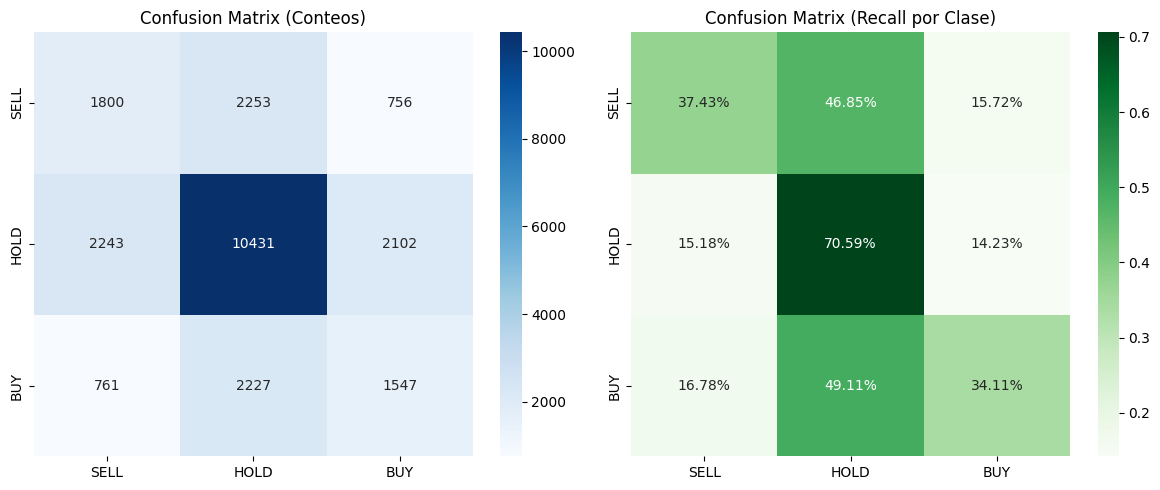


⭐ Métricas Globales:
Accuracy: 0.5712
F1-Score (Macro): 0.4744  <-- Si es < 0.33, el modelo es puro azar


{'accuracy': 0.5712271973466003, 'f1_macro': 0.47443657363401237}

In [21]:
evaluate_model_classification(res)

In [22]:
res

,fold,datetime,actual,prob_hold,prob_move,prob_sell,prob_buy,pred_logret,real_logret,pred_move,pred_dir,final_pred
0,1,2010-10-18 16:00:00,0.0,NaN,NaN,NaN,NaN,NaN,-0.016704,0,1,1
1,1,2010-10-18 20:00:00,1.0,NaN,NaN,NaN,NaN,NaN,-0.011259,0,1,1
2,1,2010-10-19 00:00:00,1.0,NaN,NaN,NaN,NaN,NaN,-0.008217,0,1,1
3,1,2010-10-19 04:00:00,1.0,NaN,NaN,NaN,NaN,NaN,-0.003267,0,1,1
4,1,2010-10-19 08:00:00,1.0,NaN,NaN,NaN,NaN,NaN,-0.008436,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
24115,134,2026-01-13 08:00:00,1.0,0.451255,0.548745,0.459316,0.540684,0.027760,0.027770,0,1,1
24116,134,2026-01-13 12:00:00,1.0,0.375172,0.624828,0.672665,0.327335,0.024817,0.028560,0,1,1
24117,134,2026-01-13 16:00:00,2.0,0.336015,0.663985,0.675290,0.324710,0.022832,0.027746,0,1,1
24118,134,2026-01-13 20:00:00,2.0,0.349066,0.650934,0.697550,0.302450,0.018787,0.018535,0,1,1


In [23]:
import os
import joblib
def save_trading_model_3level(model_l1, model_l2, model_l3, scaler, scaler_l3, features_list, model_params, res, best_thresholds=None, path="trading_model_3level"):
    """Guarda los tres modelos del pipeline de tres niveles."""
    if not os.path.exists(path):
        os.makedirs(path)
    
    # Modelos
    torch.save(model_l1.state_dict(), os.path.join(path, "model_l1_weights.pth"))
    torch.save(model_l2.state_dict(), os.path.join(path, "model_l2_weights.pth"))
    torch.save(model_l3.state_dict(), os.path.join(path, "model_l3_weights.pth"))
    
    # Scaler, features y params
    joblib.dump(scaler,        os.path.join(path, "scaler.pkl"))
    joblib.dump(scaler_l3,     os.path.join(path, "scaler_l3.pkl"))
    joblib.dump(features_list, os.path.join(path, "features.pkl"))
    joblib.dump(model_params,  os.path.join(path, "model_params.pkl"))
    
    # Umbral óptimo
    if best_thresholds is not None:
        joblib.dump(best_thresholds, os.path.join(path, "best_thresholds.pkl"))
    
    parquet_path = os.path.join(path, "res.parquet")
    res.to_parquet(parquet_path, index=False)
    
    print(f"✅ Modelos L1 y L2 guardados en: {path}")

In [24]:
model_params = {"input_dim": len(features_finales_test), "output_dim": 2}


In [25]:
# save_trading_model_3level(
#     model_l1, model_l2, model_l3,
#     sc,
#     sc_l3,
#     features_finales_test,
#     model_params,
#     res,
#     best_thresholds=best_params,
#     path=f"{MODELS_DIR}/{ASSET.lower()}/trading_model_lstm_3level"
# )

In [26]:
res

,fold,datetime,actual,prob_hold,prob_move,prob_sell,prob_buy,pred_logret,real_logret,pred_move,pred_dir,final_pred
0,1,2010-10-18 16:00:00,0.0,NaN,NaN,NaN,NaN,NaN,-0.016704,0,1,1
1,1,2010-10-18 20:00:00,1.0,NaN,NaN,NaN,NaN,NaN,-0.011259,0,1,1
2,1,2010-10-19 00:00:00,1.0,NaN,NaN,NaN,NaN,NaN,-0.008217,0,1,1
3,1,2010-10-19 04:00:00,1.0,NaN,NaN,NaN,NaN,NaN,-0.003267,0,1,1
4,1,2010-10-19 08:00:00,1.0,NaN,NaN,NaN,NaN,NaN,-0.008436,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
24115,134,2026-01-13 08:00:00,1.0,0.451255,0.548745,0.459316,0.540684,0.027760,0.027770,0,1,1
24116,134,2026-01-13 12:00:00,1.0,0.375172,0.624828,0.672665,0.327335,0.024817,0.028560,0,1,1
24117,134,2026-01-13 16:00:00,2.0,0.336015,0.663985,0.675290,0.324710,0.022832,0.027746,0,1,1
24118,134,2026-01-13 20:00:00,2.0,0.349066,0.650934,0.697550,0.302450,0.018787,0.018535,0,1,1


In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model_regression(results):
    """
    Evalúa el rendimiento del modelo L3 (regresión de log-return).
    Requiere columnas:
        - pred_logret
        - real_logret
    """

    df = results.copy()
    df = df.dropna(subset=["pred_logret", "real_logret"])

    y_true = df["real_logret"].astype(float).values
    y_pred = df["pred_logret"].astype(float).values

    # -----------------------------
    # 1. Métricas numéricas
    # -----------------------------
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    corr = np.corrcoef(y_true, y_pred)[0, 1]

    print("📈 --- MÉTRICAS REGRESIÓN L3 ---")
    print(f"MAE :  {mae:.6f}")
    print(f"RMSE:  {rmse:.6f}")
    print(f"R²  :  {r2:.4f}")
    print(f"Correlación pred-real: {corr:.4f}")

    # -----------------------------
    # 2. Scatter plot pred vs real
    # -----------------------------
    plt.figure(figsize=(6, 6))
    sns.scatterplot(x=y_true, y=y_pred, s=10, alpha=0.4)
    plt.xlabel("Real log-return")
    plt.ylabel("Predicted log-return")
    plt.title("Scatter Pred vs Real (L3)")
    plt.axhline(0, color='gray', linestyle='--', linewidth=1)
    plt.axvline(0, color='gray', linestyle='--', linewidth=1)
    plt.grid(alpha=0.3)
    plt.show()

    # -----------------------------
    # 3. Histograma de errores
    # -----------------------------
    errors = y_pred - y_true

    plt.figure(figsize=(6, 4))
    sns.histplot(errors, bins=50, kde=True)
    plt.title("Distribución del Error (pred - real)")
    plt.xlabel("Error")
    plt.grid(alpha=0.3)
    plt.show()

    # -----------------------------
    # 4. KDE conjunto (densidad)
    # -----------------------------
    plt.figure(figsize=(6, 6))
    sns.kdeplot(x=y_true, y=y_pred, fill=True, cmap="viridis", thresh=0.05)
    plt.xlabel("Real log-return")
    plt.ylabel("Predicted log-return")
    plt.title("Densidad conjunta Pred vs Real (L3)")
    plt.grid(alpha=0.3)
    plt.show()

    return {
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "corr": corr
    }


📈 --- MÉTRICAS REGRESIÓN L3 ---
MAE :  0.004390
RMSE:  0.006603
R²  :  0.7730
Correlación pred-real: 0.8795


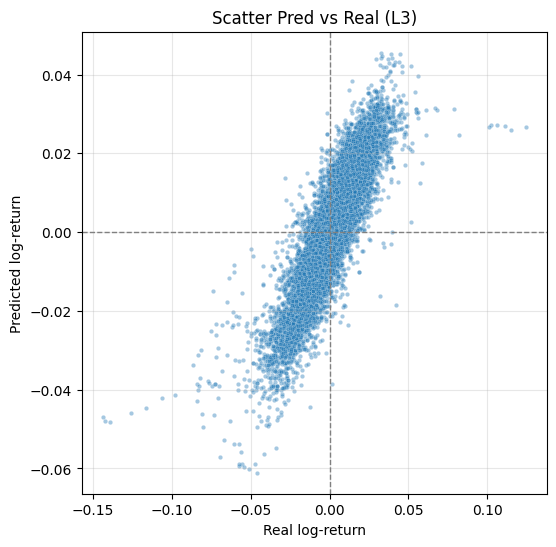

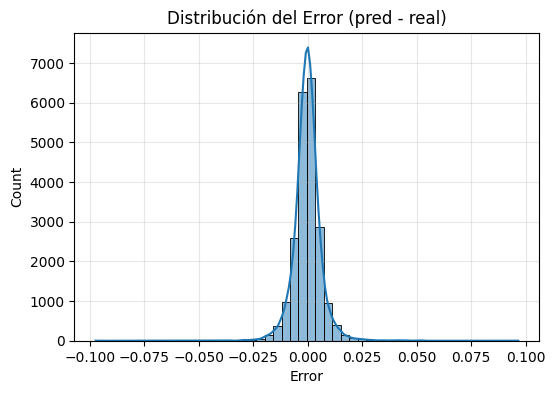

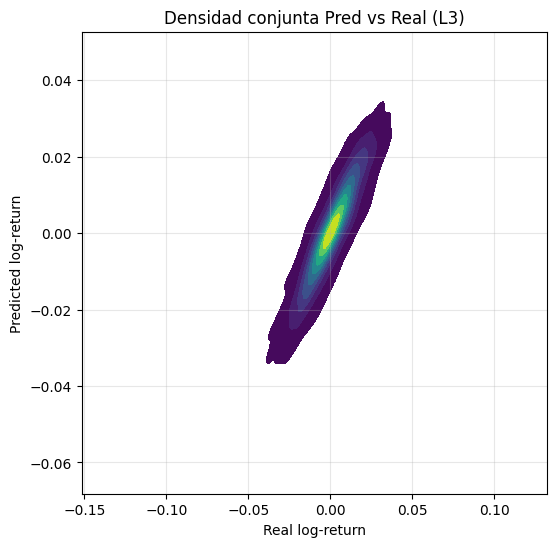

{'mae': 0.004389890609904082,
 'rmse': np.float64(0.006602562613381237),
 'r2': 0.7729596318442729,
 'corr': np.float64(0.8794785256414904)}

In [28]:
evaluate_model_regression(res)

In [29]:
result_3_g, result_by_fold_3_g, df_losses_g, model_l1_g, model_l2_g, model_l3_g, sc_g, sc_l3_g = train_walk_forward_3level(df_final_triple_real, features_finales_test, 'target_class', 'target_regression', BasicGRU_L1_Move, BasicGRU_L2_Dir, BasicGRU_L3_Regression, 
                            train_size=params["train_size"],
                            test_size=params["test_size"],
                            gap=params["gap"],
                            lookback=params["lookback"],
                            epochs=15,
                            batch_size=256,
                            lr=5e-4)


WF 3-Level:   0%|          | 0/134 [00:00<?, ?it/s]C:\Users\LIJUN\AppData\Local\Temp\ipykernel_2056\2617823288.py:121: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sched_l1.step()
C:\Users\LIJUN\AppData\Local\Temp\ipykernel_2056\2617823288.py:167: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  sched_l2.step

In [30]:
best_params_g, df_grid_g = grid_search_thresholds(result_3_g)


Métrica: f1_macro
Mejor score: 0.4826 con {'threshold_move': 0.65, 'threshold_dir': 0.5}

Top 10:
 threshold_move  threshold_dir  f1_macro
           0.65           0.50    0.4826
           0.65            NaN    0.4826
           0.70            NaN    0.4807
           0.70           0.50    0.4807
           0.65           0.55    0.4798
           0.60            NaN    0.4757
           0.60           0.50    0.4757
           0.70           0.55    0.4754
           0.60           0.55    0.4751
           0.65           0.60    0.4729


In [31]:
res_g = get_predict(result_3_g, best_params_g)

In [ ]:
model_params_g = {"input_dim": len(features_finales_test), "output_dim": 2, "lookback": params["lookback"]}


In [33]:
# save_trading_model_3level(
#         model_l1_g, model_l2_g, model_l3_g,
#         sc_g,
#         sc_l3_g,
#         features_finales_test,
#         model_params_g,
#         res_g,
#         best_thresholds=best_params_g,
#         path=f"{MODELS_DIR}/{ASSET.lower()}/trading_model_gru_3level"
#     )

📊 --- CLASIFICACIÓN POR CLASE ---
              precision    recall  f1-score   support

    SELL (0)       0.37      0.42      0.40      4809
    HOLD (1)       0.71      0.64      0.68     14776
     BUY (2)       0.35      0.41      0.37      4535

    accuracy                           0.55     24120
   macro avg       0.48      0.49      0.48     24120
weighted avg       0.58      0.55      0.56     24120



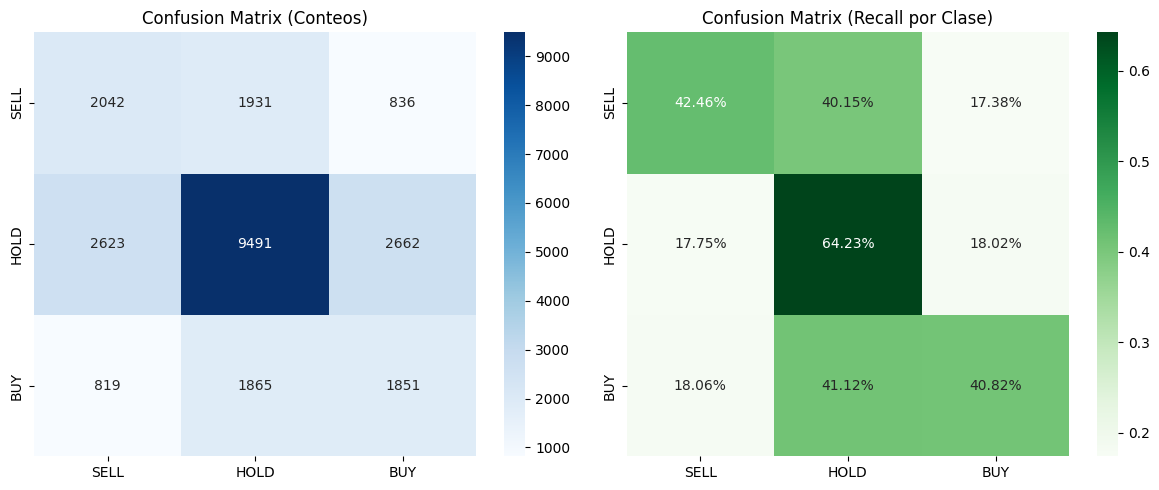


⭐ Métricas Globales:
Accuracy: 0.5549
F1-Score (Macro): 0.4826  <-- Si es < 0.33, el modelo es puro azar


{'accuracy': 0.5548922056384743, 'f1_macro': 0.4825752940451258}

In [34]:
evaluate_model_classification(res_g)

📈 --- MÉTRICAS REGRESIÓN L3 ---
MAE :  0.004078
RMSE:  0.006277
R²  :  0.7948
Correlación pred-real: 0.8916


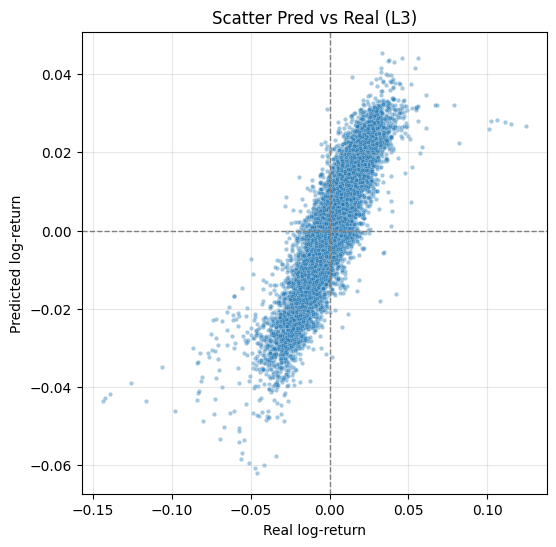

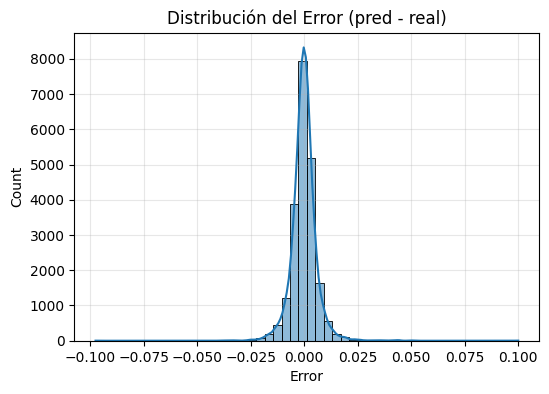

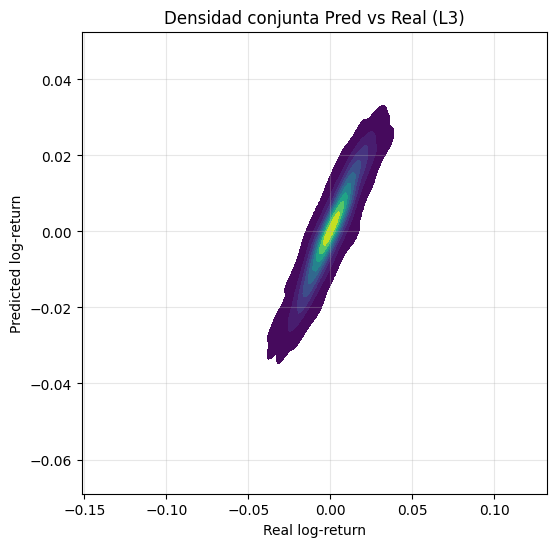

{'mae': 0.004078134404746286,
 'rmse': np.float64(0.006277459893342729),
 'r2': 0.7947676023229051,
 'corr': np.float64(0.8915719106409239)}

In [35]:
evaluate_model_regression(res_g)

In [36]:
df_losses

,fold,epoch,loss_l1_move,loss_l2_dir,loss_l3_reg
0,1,1,0.696090,NaN,NaN
1,1,2,0.694972,NaN,NaN
2,1,3,0.693328,NaN,NaN
3,1,4,0.692178,NaN,NaN
4,1,5,0.691030,NaN,NaN
...,...,...,...,...,...
2005,134,11,0.550395,0.476985,0.048799
2006,134,12,0.539429,0.464430,0.047018
2007,134,13,0.533823,0.470408,0.045687
2008,134,14,0.530422,0.467329,0.046044


In [43]:
df_losses.loss_l1_move.mean()

np.float64(0.5836101210226996)

In [42]:
from sklearn.metrics import log_loss

df = res.copy()

# Filtrar solo filas con predicción válida
df = df.dropna(subset=["prob_move", "prob_hold"])

# Etiqueta real: 0 = HOLD, 1 = MOVE
y_true_L1 = (df["actual"] != 0).astype(int)

# Probabilidad de clase positiva (MOVE)
y_prob_L1 = df["prob_move"]

# Calcular log-loss
test_loss_L1 = log_loss(y_true_L1, y_prob_L1)
test_loss_L1


0.8160319946208353

In [44]:
params

{'lookback': 30,
 'train_size': 6000,
 'test_size': 180,
 'gap': 12,
 '_candles_per_day': 6,
 '_horizon_bars': 12}

In [52]:
res

,fold,datetime,actual,prob_hold,prob_move,prob_sell,prob_buy,pred_logret,real_logret,pred_move,pred_dir,final_pred
0,1,2010-10-18 16:00:00,0.0,NaN,NaN,NaN,NaN,NaN,-0.016704,0,1,1
1,1,2010-10-18 20:00:00,1.0,NaN,NaN,NaN,NaN,NaN,-0.011259,0,1,1
2,1,2010-10-19 00:00:00,1.0,NaN,NaN,NaN,NaN,NaN,-0.008217,0,1,1
3,1,2010-10-19 04:00:00,1.0,NaN,NaN,NaN,NaN,NaN,-0.003267,0,1,1
4,1,2010-10-19 08:00:00,1.0,NaN,NaN,NaN,NaN,NaN,-0.008436,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
24115,134,2026-01-13 08:00:00,1.0,0.451255,0.548745,0.459316,0.540684,0.027760,0.027770,0,1,1
24116,134,2026-01-13 12:00:00,1.0,0.375172,0.624828,0.672665,0.327335,0.024817,0.028560,0,1,1
24117,134,2026-01-13 16:00:00,2.0,0.336015,0.663985,0.675290,0.324710,0.022832,0.027746,0,1,1
24118,134,2026-01-13 20:00:00,2.0,0.349066,0.650934,0.697550,0.302450,0.018787,0.018535,0,1,1


In [55]:
lista_no_na = res.dropna(subset=["prob_move", "prob_hold"]).fold.unique()

In [45]:
from sklearn.metrics import log_loss

df = res.copy()

# Filtrar solo filas con predicción válida
df = df.dropna(subset=["prob_move", "prob_hold"])

test_size = 180

# Número de folds
n_folds = len(df) // test_size

losses_L1 = []

for i in range(n_folds):
    start = i * test_size
    end = start + test_size
    fold_df = df.iloc[start:end]

    # Etiqueta real: 0 = HOLD, 1 = MOVE
    y_true = (fold_df["actual"] != 0).astype(int)

    # Probabilidad de clase positiva (MOVE)
    y_prob = fold_df["prob_move"]

    # Log-loss del fold
    fold_loss = log_loss(y_true, y_prob)
    losses_L1.append(fold_loss)

losses_L1


[0.9115152204063619,
 0.7955949181737042,
 0.7321979927121418,
 0.9474941433630755,
 0.6789046334416042,
 0.6130190164049514,
 0.8730671468129404,
 0.7804267218066855,
 0.8824903266192602,
 0.6884691867455996,
 0.876052971582654,
 1.129735077203711,
 1.122601564552786,
 0.9713339794924097,
 0.7084045377600555,
 0.9098509838297526,
 0.9465091904628417,
 0.8648388260454112,
 0.966955296923875,
 0.7407817308377885,
 1.134917591238562,
 0.9194980316912406,
 0.9024270380545851,
 0.8064558862570357,
 0.7498790864348103,
 0.8967306594916633,
 0.6540313220007287,
 0.5326687109049677,
 0.8018776222462198,
 0.9402799131225196,
 0.7661328010962571,
 0.829410395101012,
 0.8647314660058683,
 0.9227228726215682,
 0.8889245522958928,
 0.7757403920019079,
 0.985992374372944,
 0.7474948324641514,
 0.8968057262197502,
 0.8297904062124745,
 0.6376732310164095,
 0.7122318306991946,
 0.7116752366812928,
 0.6780802522694676,
 0.8157785033887167,
 0.7397956107654847,
 0.697324776163798,
 0.665612809060955,
 

In [61]:
df_prueba = df_losses.groupby('fold')['loss_l1_move'].last().reset_index()

In [64]:
df_prueba = df_prueba[df_prueba.fold.isin(lista_no_na)]

In [65]:
df_prueba['loss_l1_move_test'] = losses_L1

In [69]:
df_prueba.to_dict()

{'fold': {2: 3,
  3: 4,
  4: 5,
  5: 6,
  6: 7,
  7: 8,
  8: 9,
  9: 10,
  10: 11,
  11: 12,
  12: 13,
  13: 14,
  14: 15,
  15: 16,
  16: 17,
  17: 18,
  18: 19,
  19: 20,
  20: 21,
  21: 22,
  22: 23,
  23: 24,
  24: 25,
  25: 26,
  26: 27,
  27: 28,
  28: 29,
  29: 30,
  30: 31,
  31: 32,
  32: 33,
  33: 34,
  34: 35,
  35: 36,
  36: 37,
  37: 38,
  38: 39,
  39: 40,
  40: 41,
  53: 54,
  54: 55,
  55: 56,
  56: 57,
  57: 58,
  58: 59,
  59: 60,
  60: 61,
  61: 62,
  62: 63,
  63: 64,
  64: 65,
  65: 66,
  66: 67,
  67: 68,
  68: 69,
  69: 70,
  70: 71,
  71: 72,
  72: 73,
  73: 74,
  74: 75,
  75: 76,
  76: 77,
  77: 78,
  78: 79,
  79: 80,
  80: 81,
  81: 82,
  82: 83,
  83: 84,
  84: 85,
  85: 86,
  86: 87,
  87: 88,
  88: 89,
  89: 90,
  90: 91,
  91: 92,
  92: 93,
  93: 94,
  94: 95,
  95: 96,
  96: 97,
  97: 98,
  98: 99,
  99: 100,
  100: 101,
  101: 102,
  102: 103,
  103: 104,
  104: 105,
  105: 106,
  106: 107,
  107: 108,
  108: 109,
  109: 110,
  110: 111,
  111: 112,
  

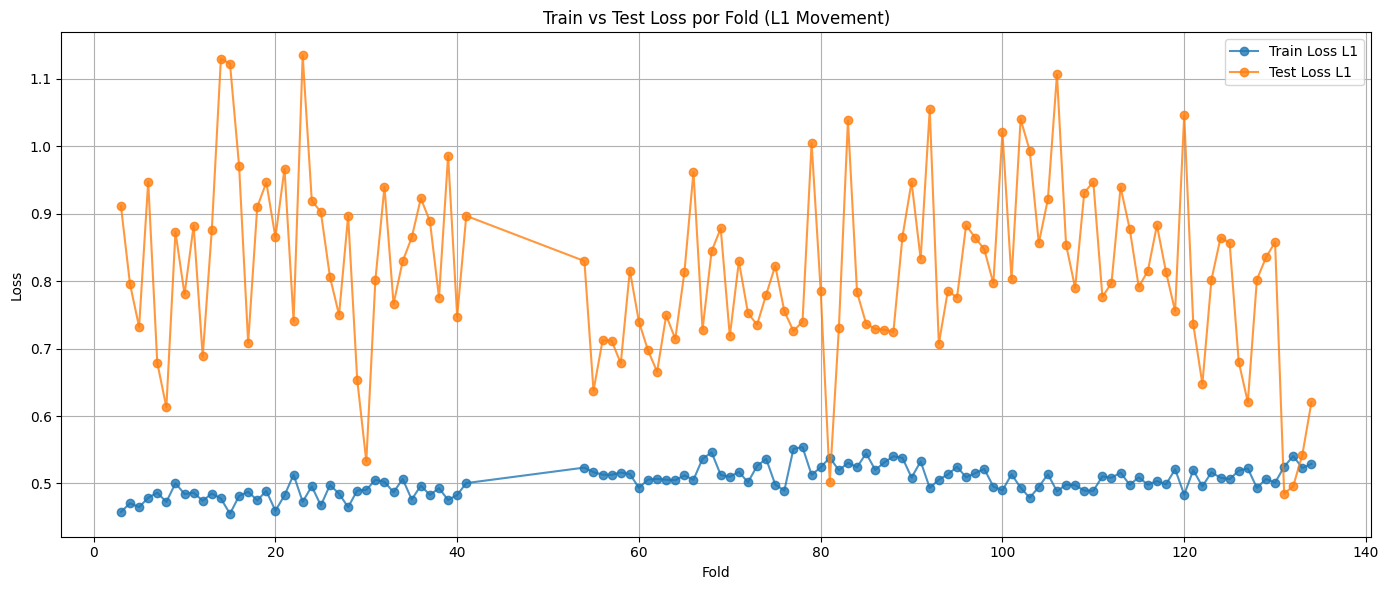

In [68]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(df_prueba["fold"], df_prueba["loss_l1_move"], 
         label="Train Loss L1", marker="o", alpha=0.8)

plt.plot(df_prueba["fold"], df_prueba["loss_l1_move_test"], 
         label="Test Loss L1", marker="o", alpha=0.8)

plt.xlabel("Fold")
plt.ylabel("Loss")
plt.title("Train vs Test Loss por Fold (L1 Movement)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
